In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NYC_Data.csv to NYC_Data.csv
Saving LA_Data.csv to LA_Data.csv


In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#Load the datasets
la_df = pd.read_csv("LA_Data.csv")
nyc_df = pd.read_csv("NYC_Data.csv")

#copy for cleaning to preserve original data
la_clean = la_df.copy()
nyc_clean = nyc_df.copy()

In [ ]:
print("LA Columns:", la_clean.columns.tolist())
print("NYC Columns:", nyc_clean.columns.tolist())

LA Columns: ['Date', 'Source', 'POC', 'Daily Max 8-hour CO Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Pollutant', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']
NYC Columns: ['Date', 'Source', 'POC', 'Daily Max 8-hour CO Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Pollutant', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']


In [ ]:
la_clean.rename(columns={'Daily AQI Value': 'AQI'}, inplace=True)
nyc_clean.rename(columns={'Daily AQI Value': 'AQI'}, inplace=True)

In [ ]:
la_clean['Date'] = pd.to_datetime(la_clean['Date'], errors='coerce')
nyc_clean['Date'] = pd.to_datetime(nyc_clean['Date'], errors='coerce')

Missing Data

In [ ]:
print(f"LA missing dates: {la_clean['Date'].isna().sum()}")
print(f"NYC missing dates: {nyc_clean['Date'].isna().sum()}")
la_clean = la_clean.dropna(subset=['Date'])
nyc_clean = nyc_clean.dropna(subset=['Date'])

LA missing dates: 0
NYC missing dates: 0


Month Grouping

In [ ]:
la_clean['Year'] = la_clean['Date'].dt.year
la_clean['Month'] = la_clean['Date'].dt.month
la_clean['YearMonth'] = la_clean['Date'].dt.to_period('M')
nyc_clean['Year'] = nyc_clean['Date'].dt.year
nyc_clean['Month'] = nyc_clean['Date'].dt.month
nyc_clean['YearMonth'] = nyc_clean['Date'].dt.to_period('M')

In [ ]:
print(f"LA duplicates: {la_clean.duplicated().sum()}")
print(f"NYC duplicates: {nyc_clean.duplicated().sum()}")

LA duplicates: 0
NYC duplicates: 0


In [ ]:
print("LA Info:")
print(la_clean.info())
print("\nNYC Info:")
print(nyc_clean.info())

LA Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               12070 non-null  datetime64[ns]
 1   Source                             12070 non-null  object        
 2   POC                                12070 non-null  int64         
 3   Daily Max 8-hour CO Concentration  3663 non-null   float64       
 4   Units                              12070 non-null  object        
 5   Daily AQI Value                    12070 non-null  int64         
 6   Local Site Name                    12070 non-null  object        
 7   Daily Obs Count                    12070 non-null  int64         
 8   Percent Complete                   12070 non-null  int64         
 9   AQS Parameter Code                 12070 non-null  int64         
 10  Pollutant                

In [ ]:
# For the entire dataset
print("LA AQI - Descriptive Stats:")
print(la_clean['AQI'].describe())
print("\nNYC AQI - Descriptive Stats:")
print(nyc_clean['AQI'].describe())

# For each year
print("\nLA AQI Stats by Year:")
print(la_clean.groupby('Year')['AQI'].describe())
print("\nNYC AQI Stats by Year:")
print(nyc_clean.groupby('Year')['AQI'].describe())

LA AQI - Descriptive Stats:
count    12070.000000
mean        29.625684
std         27.704417
min          0.000000
25%          7.000000
50%         24.000000
75%         42.000000
max        221.000000
Name: AQI, dtype: float64

NYC AQI - Descriptive Stats:
count    14697.000000
mean        22.157719
std         18.607510
min          0.000000
25%          6.000000
50%         18.000000
75%         33.000000
max        199.000000
Name: AQI, dtype: float64

LA AQI Stats by Year:
       count       mean        std  min   25%   50%    75%    max
Year                                                             
2015  1136.0  28.713028  26.341780  2.0  7.00  24.0  40.00  177.0
2016  1204.0  30.496678  28.581670  0.0  6.75  25.0  42.25  201.0
2017  1203.0  33.226933  33.015489  2.0  7.00  25.0  44.00  209.0
2018  1193.0  30.875943  29.431294  2.0  7.00  24.0  44.00  185.0
2019  1203.0  29.583541  28.576172  2.0  6.00  24.0  41.50  172.0
2020  1171.0  32.531170  34.848949  2.0  7.00  24.0  

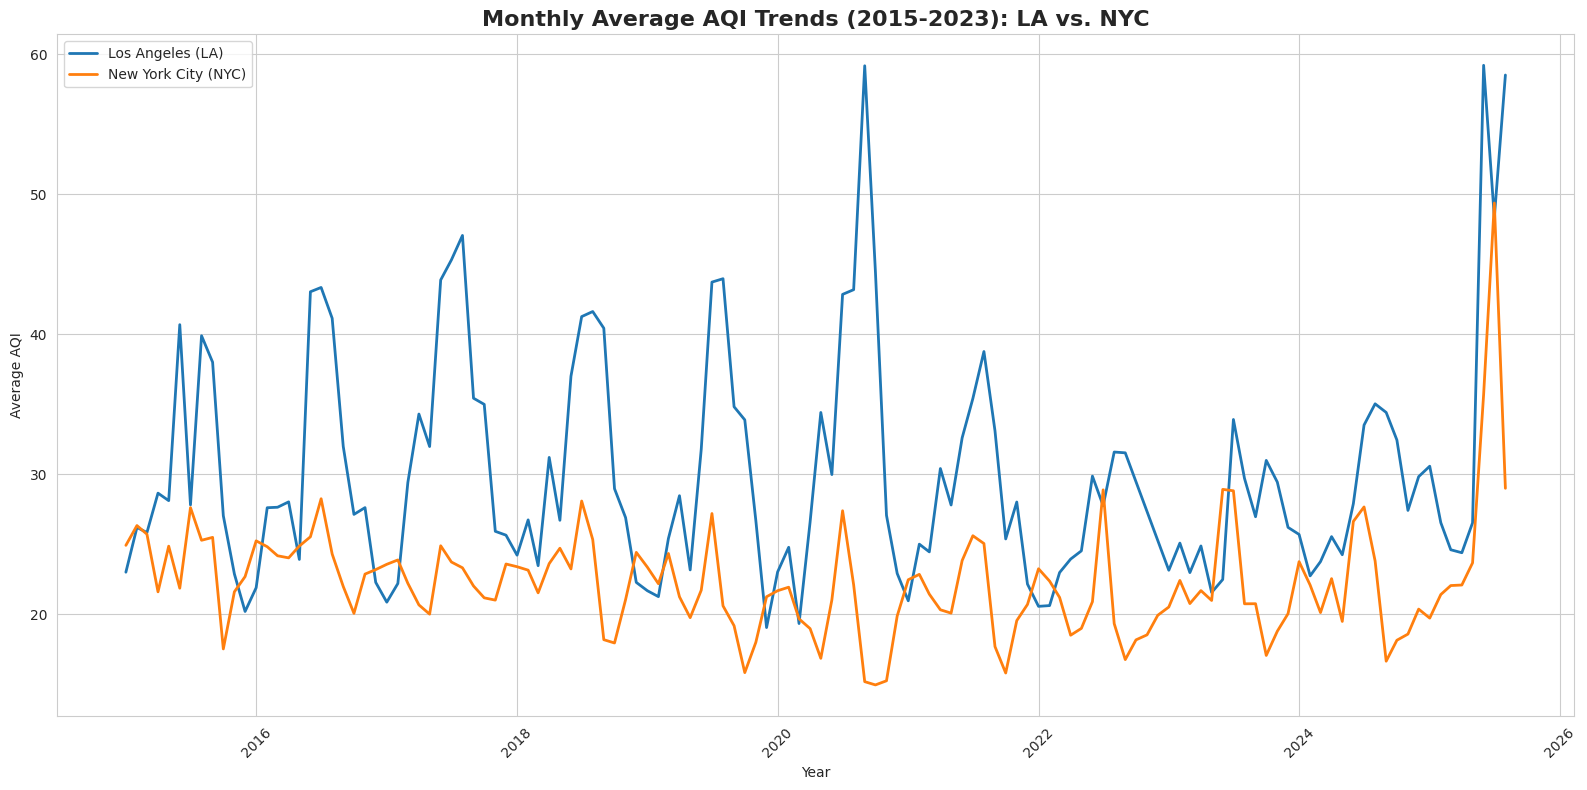

In [ ]:
#Monthly average AQI for each city
la_monthly_avg = la_clean.groupby('YearMonth')['AQI'].mean().reset_index()
nyc_monthly_avg = nyc_clean.groupby('YearMonth')['AQI'].mean().reset_index()

# Convert YearMonth period to timestamp for plotting
la_monthly_avg['YearMonth'] = la_monthly_avg['YearMonth'].dt.to_timestamp()
nyc_monthly_avg['YearMonth'] = nyc_monthly_avg['YearMonth'].dt.to_timestamp()

#Plot
plt.figure(figsize=(16, 8))
plt.plot(la_monthly_avg['YearMonth'], la_monthly_avg['AQI'], label='Los Angeles (LA)', linewidth=2)
plt.plot(nyc_monthly_avg['YearMonth'], nyc_monthly_avg['AQI'], label='New York City (NYC)', linewidth=2)

plt.title('Monthly Average AQI Trends (2015-2023): LA vs. NYC', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

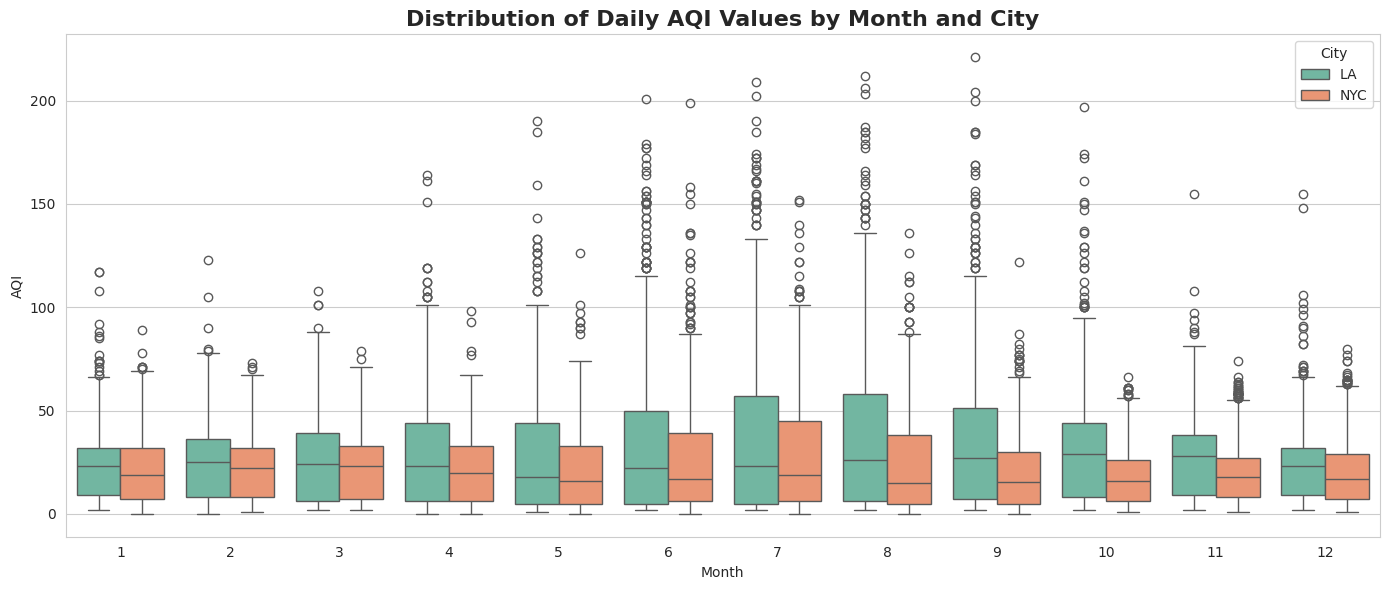

In [ ]:
plt.figure(figsize=(14, 6))

la_clean['City'] = 'LA'
nyc_clean['City'] = 'NYC'
combined_df = pd.concat([la_clean, nyc_clean], ignore_index=True)

#Boxplot
sns.boxplot(x='Month', y='AQI', hue='City', data=combined_df, palette="Set2")
plt.title('Distribution of Daily AQI Values by Month and City', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.legend(title='City')
plt.tight_layout()
plt.show()

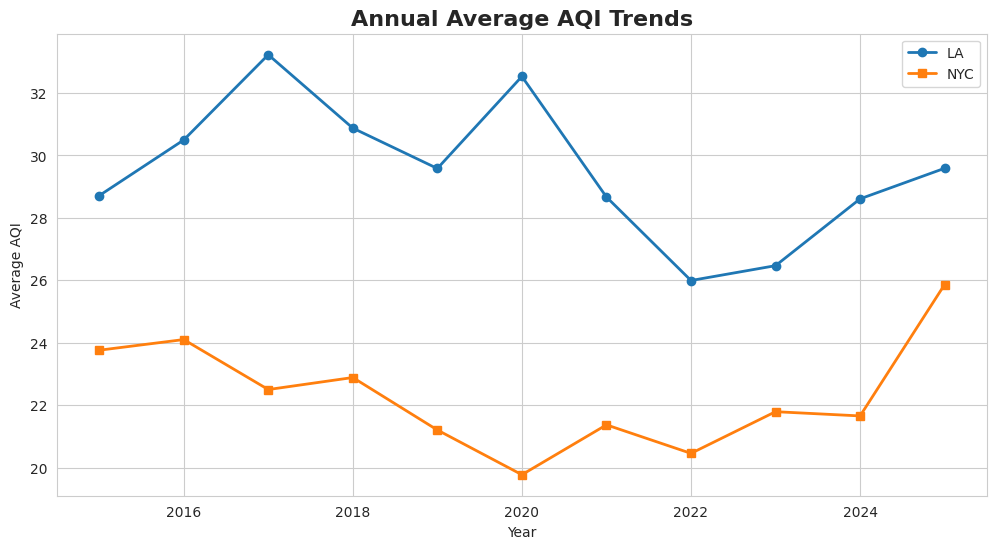

In [ ]:
# Calculate yearly average AQI
la_yearly_avg = la_clean.groupby('Year')['AQI'].mean().reset_index()
nyc_yearly_avg = nyc_clean.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(la_yearly_avg['Year'], la_yearly_avg['AQI'], marker='o', label='LA', linewidth=2)
plt.plot(nyc_yearly_avg['Year'], nyc_yearly_avg['AQI'], marker='s', label='NYC', linewidth=2)

plt.title('Annual Average AQI Trends', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend()
plt.grid(True)
plt.show()

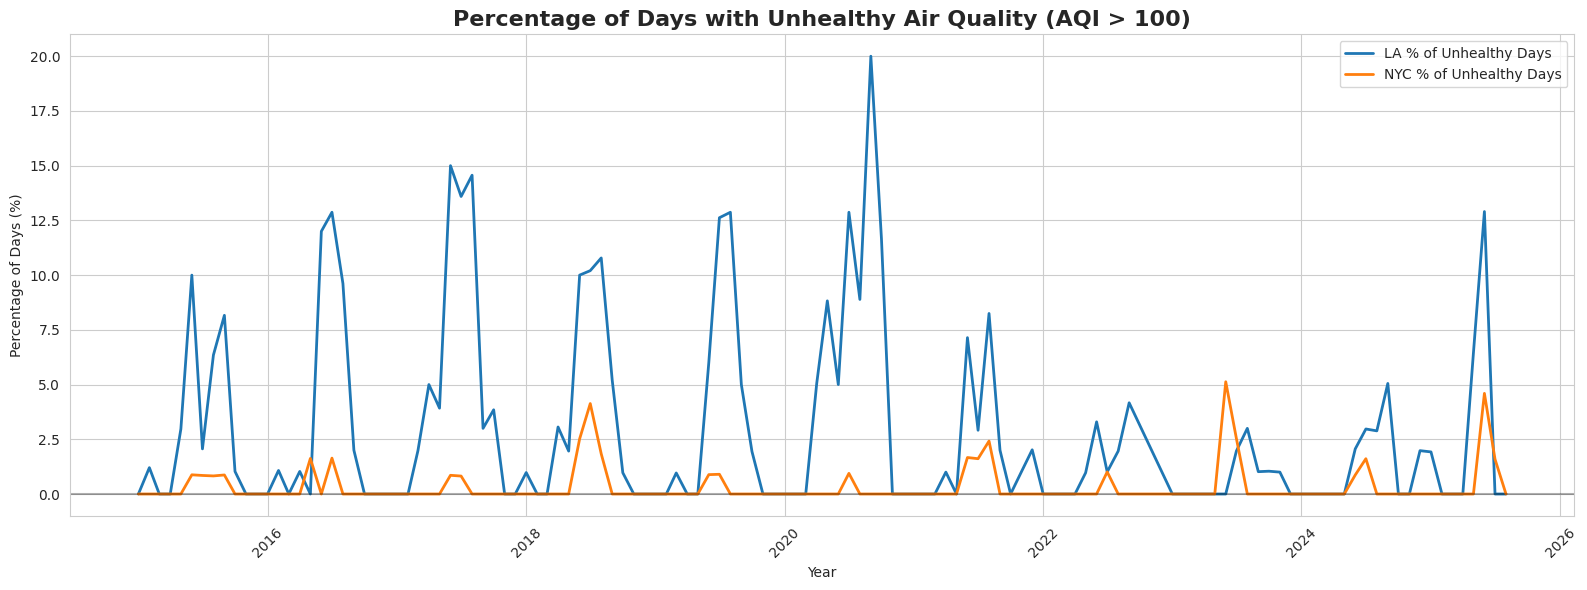

In [ ]:
#Threshold for "Unhealthy" AQI (AQI > 100)
threshold = 100

#Percentage of days each month that exceed the threshold
la_exceedance = la_clean.groupby('YearMonth')['AQI'].apply(lambda x: (x > threshold).sum() / len(x) * 100).reset_index()
nyc_exceedance = nyc_clean.groupby('YearMonth')['AQI'].apply(lambda x: (x > threshold).sum() / len(x) * 100).reset_index()

la_exceedance['YearMonth'] = la_exceedance['YearMonth'].dt.to_timestamp()
nyc_exceedance['YearMonth'] = nyc_exceedance['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
plt.plot(la_exceedance['YearMonth'], la_exceedance['AQI'], label='LA % of Unhealthy Days', linewidth=2)
plt.plot(nyc_exceedance['YearMonth'], nyc_exceedance['AQI'], label='NYC % of Unhealthy Days', linewidth=2)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3) # Base line

plt.title('Percentage of Days with Unhealthy Air Quality (AQI > 100)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage of Days (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Each Pollutants EDA

In [ ]:
print("LA Pollutants:", la_clean['Pollutant'].unique())
print("NYC Pollutants:", nyc_clean['Pollutant'].unique())

LA Pollutants: ['Carbon monoxide' 'NO2' 'Ozone' 'PM2.5']
NYC Pollutants: ['Carbon monoxide' 'NO2' 'Ozone' 'PM2.5']


In [ ]:
# For LA
la_monthly_pollutant = la_clean.groupby(['YearMonth', 'Pollutant'])['AQI'].mean().reset_index()
# For NYC
nyc_monthly_pollutant = nyc_clean.groupby(['YearMonth', 'Pollutant'])['AQI'].mean().reset_index()

# Convert YearMonth to timestamp for plotting
la_monthly_pollutant['YearMonth'] = la_monthly_pollutant['YearMonth'].dt.to_timestamp()
nyc_monthly_pollutant['YearMonth'] = nyc_monthly_pollutant['YearMonth'].dt.to_timestamp()

# Preview the result for LA
print(la_monthly_pollutant.head())

   YearMonth        Pollutant        AQI
0 2015-01-01  Carbon monoxide   6.096774
1 2015-01-01              NO2  31.586207
2 2015-01-01            Ozone  24.482759
3 2015-01-01            PM2.5  46.300000
4 2015-02-01  Carbon monoxide   6.821429


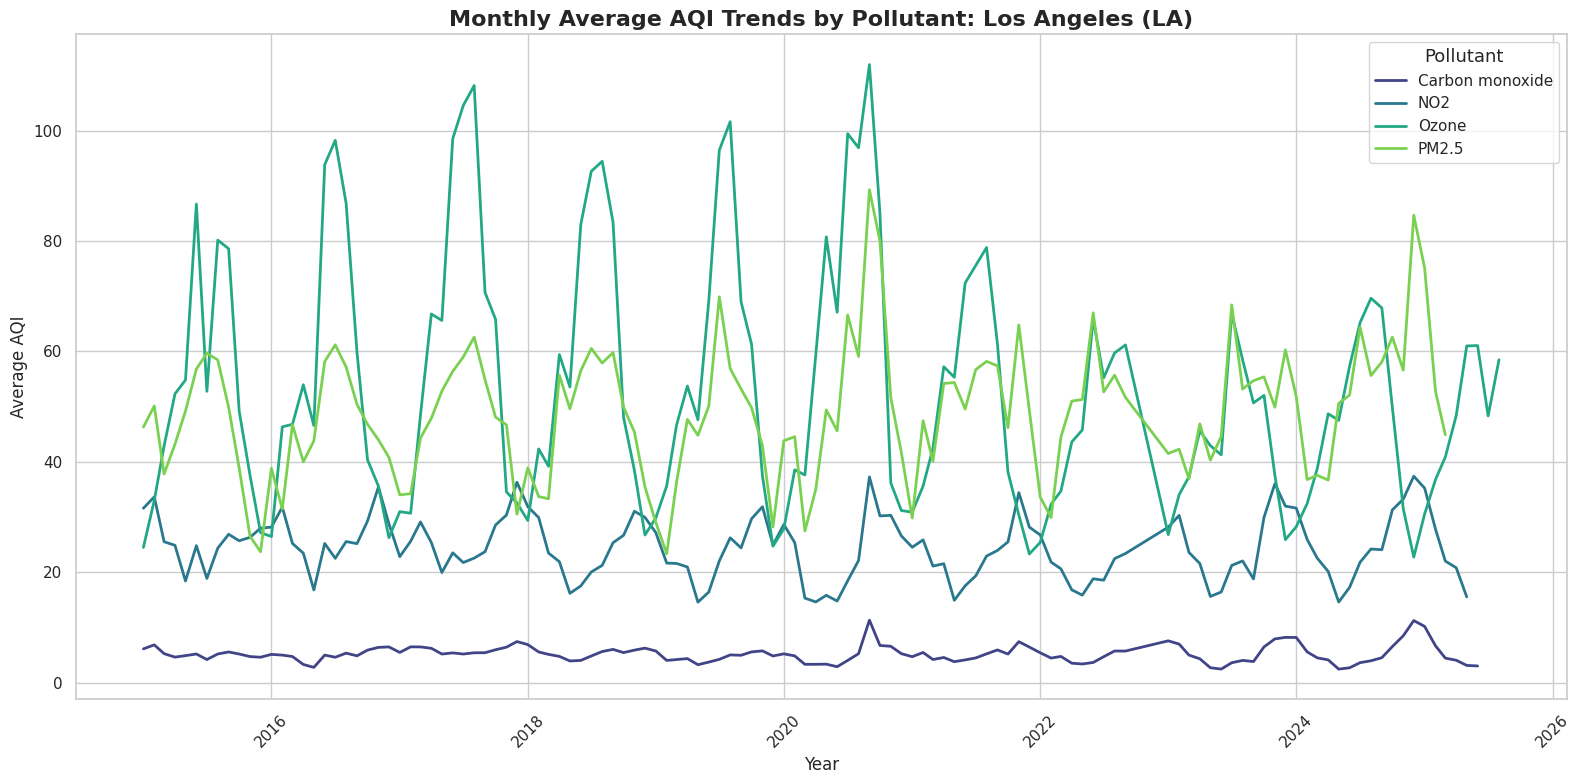

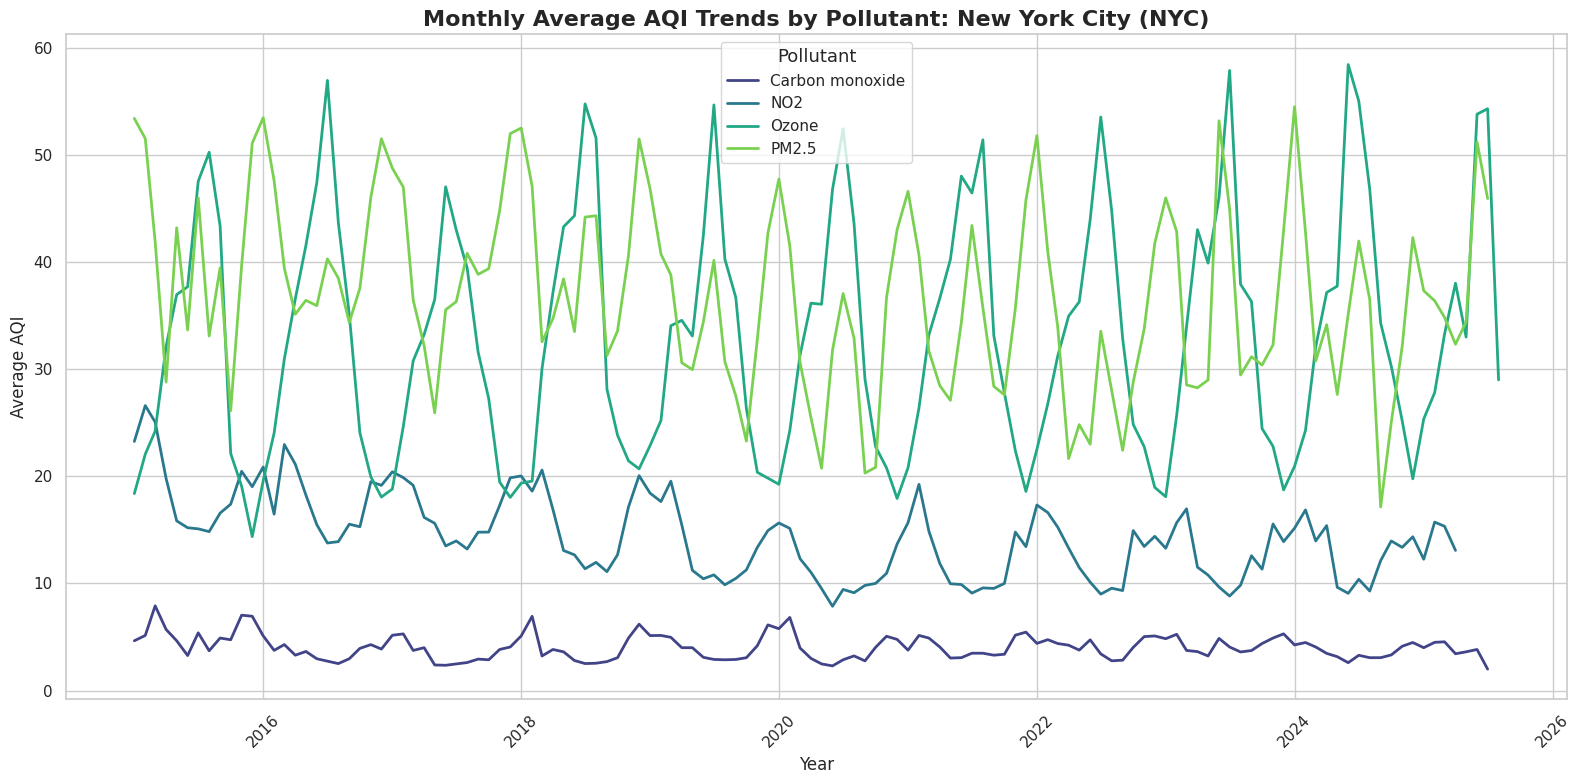

In [ ]:
#Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

def plot_pollutant_trends(df, city_name):
    plt.figure(figsize=(16, 8))
    sns.lineplot(data=df, x='YearMonth', y='AQI', hue='Pollutant', estimator=None, lw=2, palette='viridis')

    plt.title(f'Monthly Average AQI Trends by Pollutant: {city_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Average AQI')
    plt.legend(title='Pollutant', title_fontsize='13', fontsize='11')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#Los Angeles
plot_pollutant_trends(la_monthly_pollutant, 'Los Angeles (LA)')

# New York City
plot_pollutant_trends(nyc_monthly_pollutant, 'New York City (NYC)')

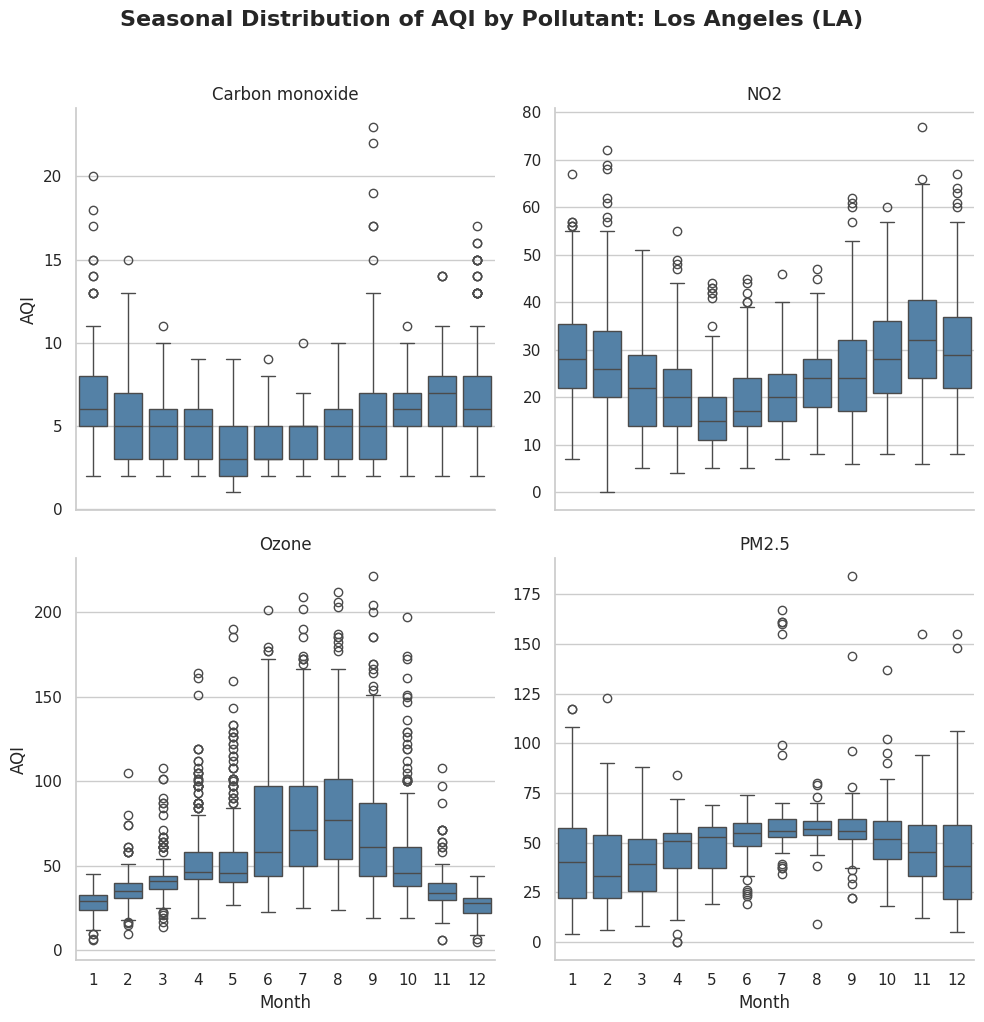

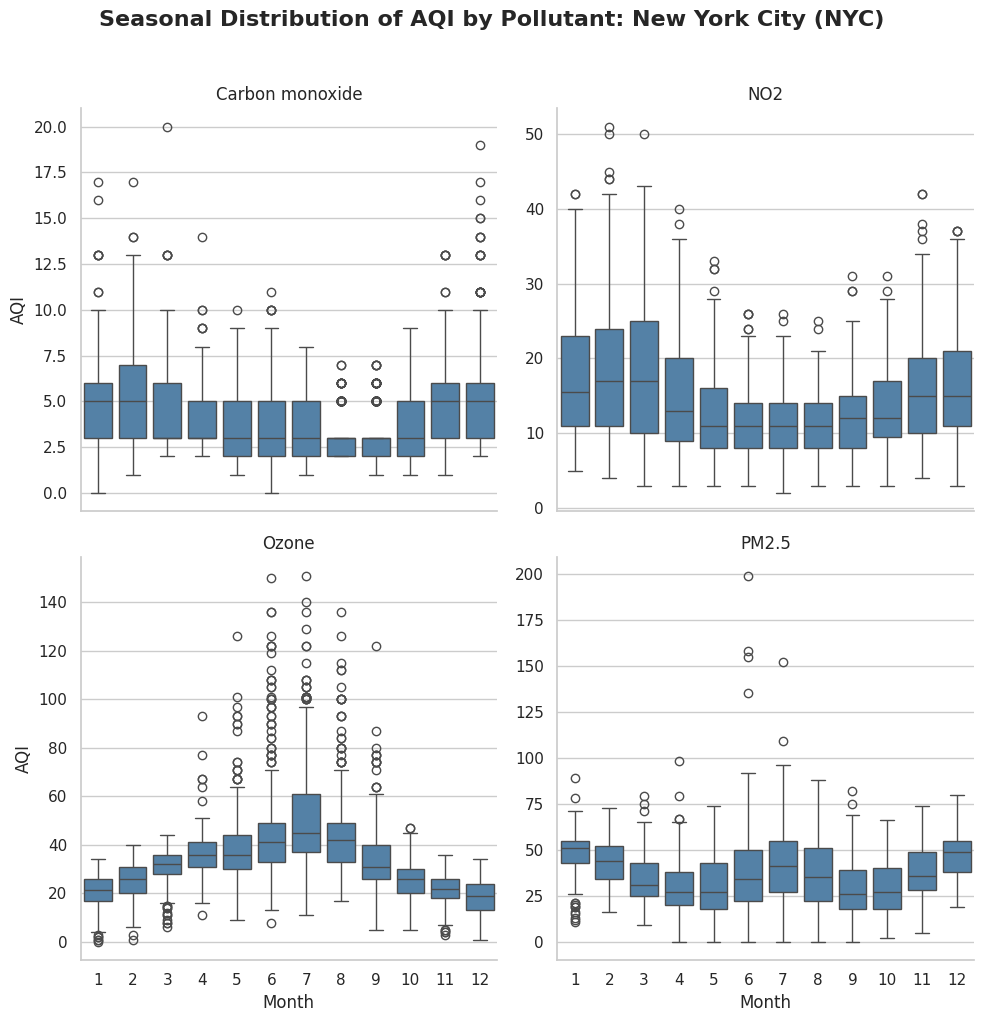

In [ ]:
#Seasonal boxplots
def plot_pollutant_seasons(df, city_name):
    g = sns.FacetGrid(df, col="Pollutant", col_wrap=2, height=5, sharey=False)
    g.map_dataframe(sns.boxplot, x='Month', y='AQI', color='steelblue')
    g.set_titles("{col_name}")
    g.fig.suptitle(f'Seasonal Distribution of AQI by Pollutant: {city_name}', fontsize=16, fontweight='bold', y=1.02)
    g.set_axis_labels("Month", "AQI")
    plt.tight_layout()
    plt.show()

#Los Angeles
plot_pollutant_seasons(la_clean, 'Los Angeles (LA)')

#New York City
plot_pollutant_seasons(nyc_clean, 'New York City (NYC)')

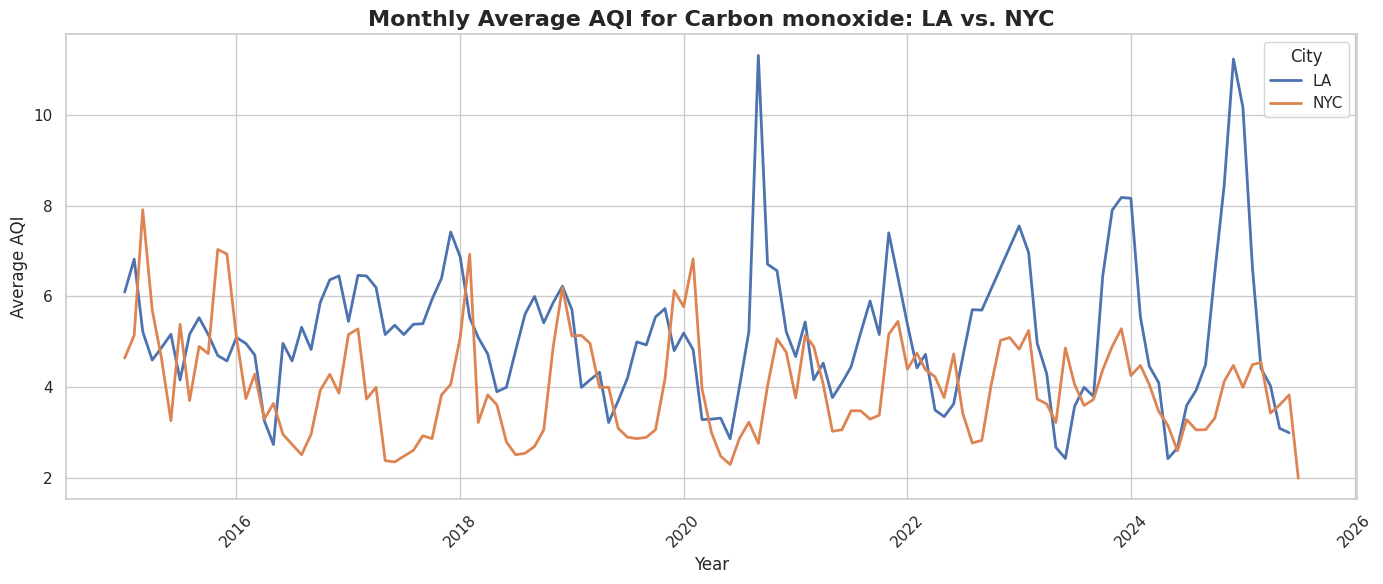

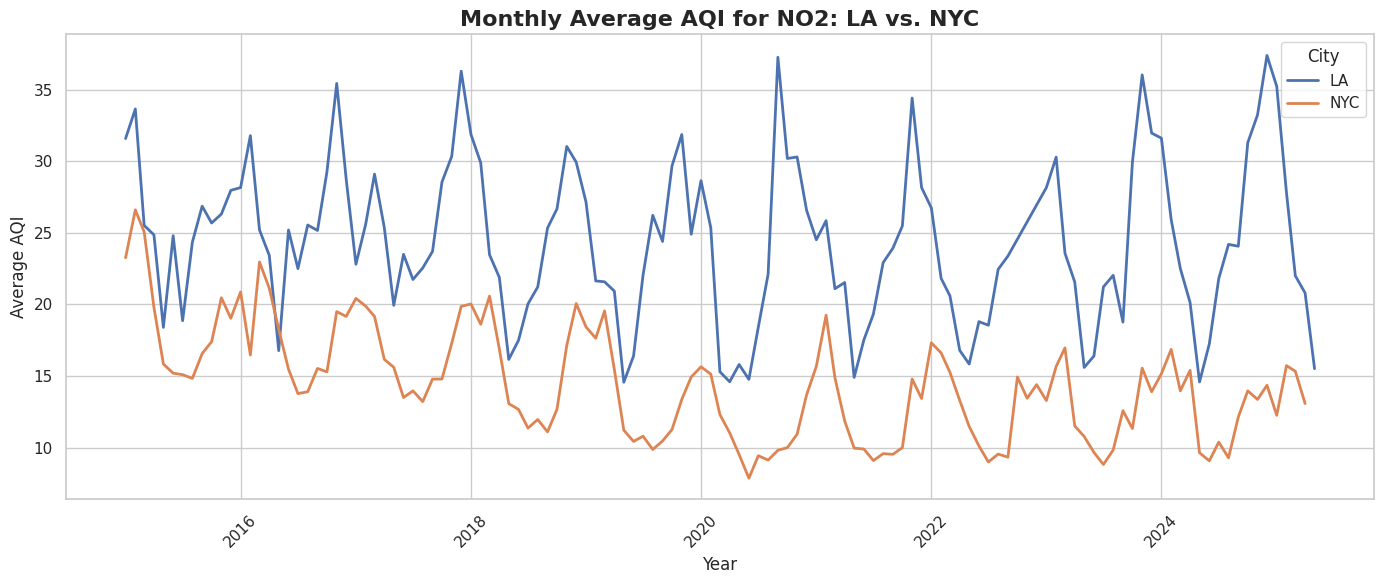

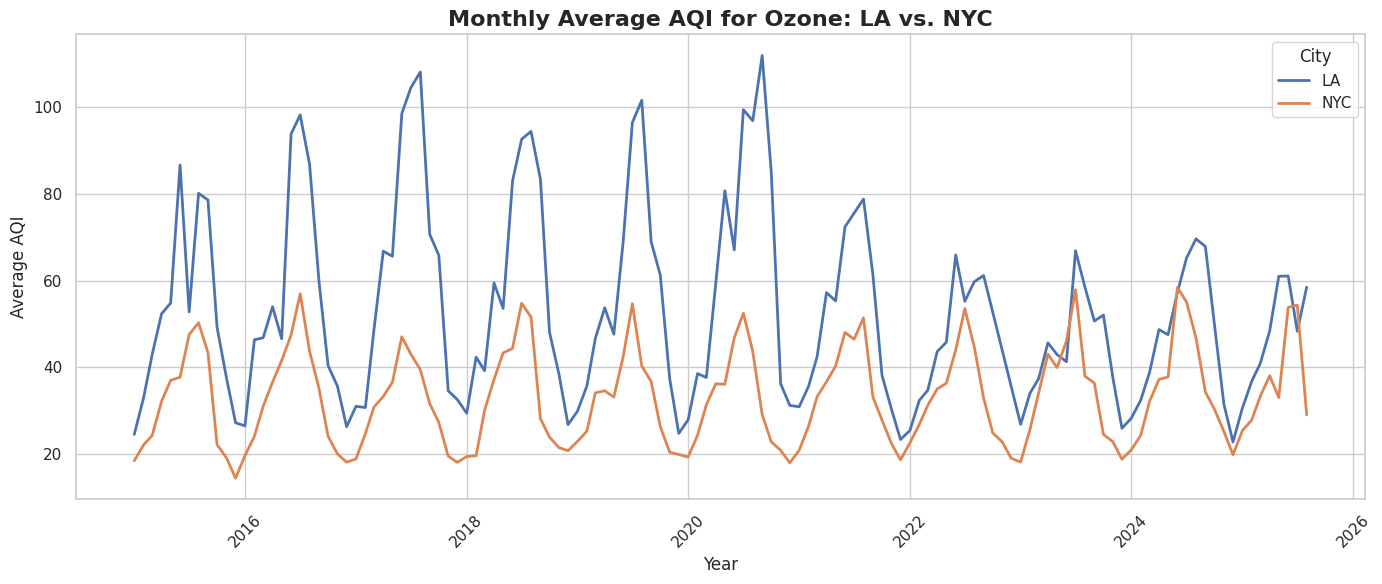

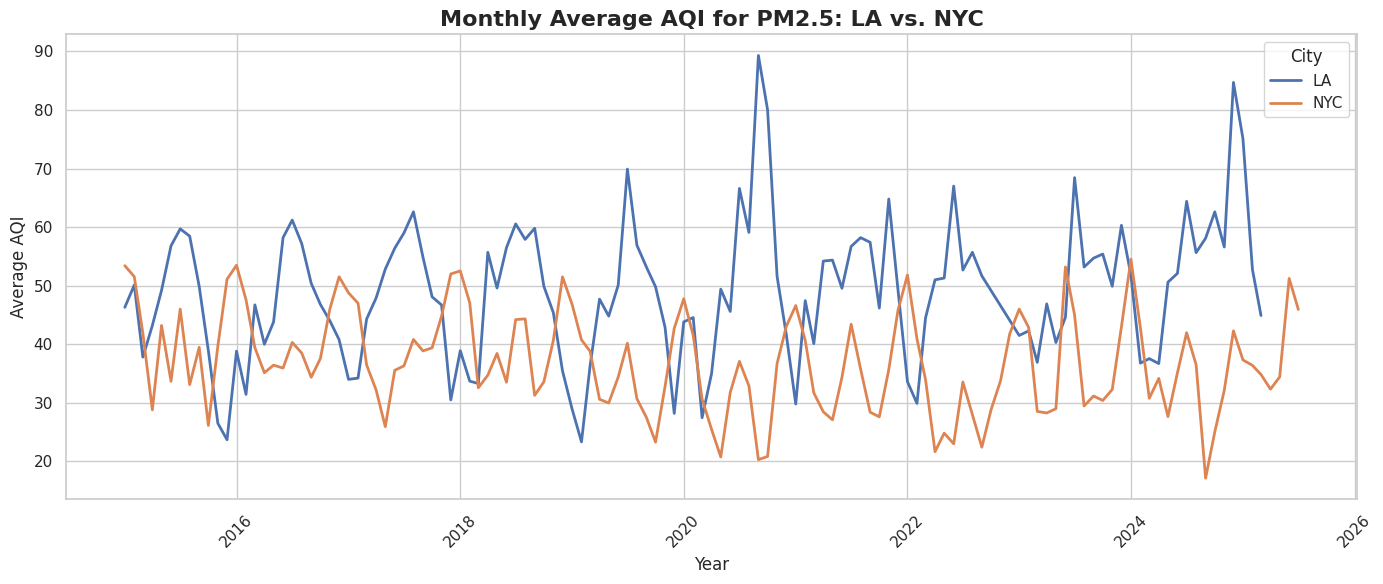

In [ ]:
#Combining the data for easier comparison
combined_pollutant = pd.concat([la_monthly_pollutant, nyc_monthly_pollutant], ignore_index=True)
combined_pollutant['City'] = ['LA'] * len(la_monthly_pollutant) + ['NYC'] * len(nyc_monthly_pollutant)

#list of unique pollutants
pollutants = combined_pollutant['Pollutant'].unique()

# Plot for each pollutant
for poll in pollutants:
    plt.figure(figsize=(14, 6))
    plot_data = combined_pollutant[combined_pollutant['Pollutant'] == poll]
    sns.lineplot(data=plot_data, x='YearMonth', y='AQI', hue='City', estimator=None, lw=2)

    plt.title(f'Monthly Average AQI for {poll}: LA vs. NYC', fontsize=16, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Average AQI')
    plt.legend(title='City')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# For LA: Mean AQI for each Pollutant for each Month
la_seasonal_summary = la_clean.groupby(['Pollutant', 'Month'])['AQI'].agg(['mean', 'std', 'count']).round(2)
print("LA - Seasonal Summary Statistics by Pollutant:")
print(la_seasonal_summary)

# For NYC: Mean AQI for each Pollutant for each Month
nyc_seasonal_summary = nyc_clean.groupby(['Pollutant', 'Month'])['AQI'].agg(['mean', 'std', 'count']).round(2)
print("\nNYC - Seasonal Summary Statistics by Pollutant:")
print(nyc_seasonal_summary)

LA - Seasonal Summary Statistics by Pollutant:
                        mean    std  count
Pollutant       Month                     
Carbon monoxide 1       6.39   2.82    339
                2       5.62   2.34    305
                3       4.70   2.04    330
                4       4.26   1.76    330
                5       3.51   1.48    338
                6       3.89   1.54    301
                7       4.32   1.31    309
                8       5.05   1.49    293
                9       5.66   2.81    293
                10      5.86   1.97    279
                11      6.60   2.47    270
                12      6.71   3.04    276
NO2             1      28.76  10.32    339
                2      27.13  11.43    303
                3      22.77  10.31    324
                4      21.07   9.29    325
                5      16.20   7.17    336
                6      19.22   7.94    299
                7      20.47   6.65    302
                8      23.34   7.56    285
       

Seasonality By Bar chart (Easier to understand)

In [ ]:
summary_df = combined_pollutant.groupby(['City', 'Pollutant'])['AQI'].mean().reset_index()

print(summary_df)

  City        Pollutant        AQI
0   LA  Carbon monoxide   5.165984
1   LA              NO2  24.400636
2   LA            Ozone  53.314706
3   LA            PM2.5  48.953652
4  NYC  Carbon monoxide   4.020528
5  NYC              NO2  14.411068
6  NYC            Ozone  33.083682
7  NYC            PM2.5  36.975304


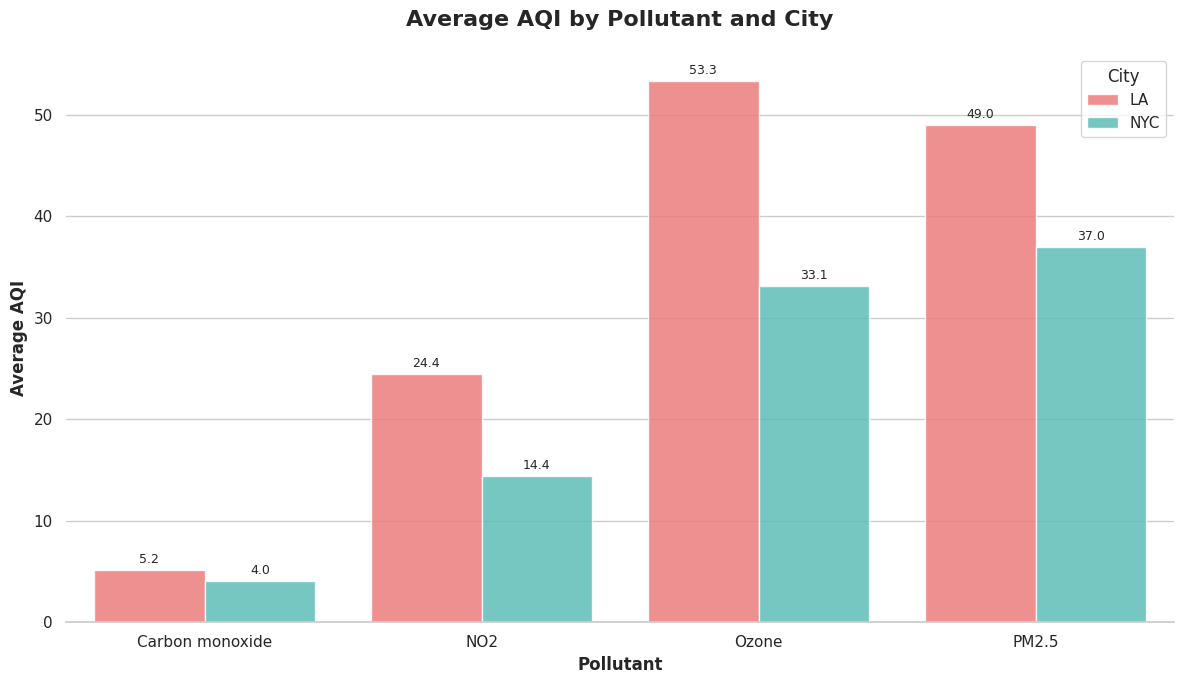

In [ ]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=summary_df,
    x='Pollutant',
    y='AQI',
    hue='City',
    palette=['#FF6B6B', '#4ECDC4'],
    alpha=0.85,
    estimator='mean',
    errorbar=None
)

# Add title and labels
plt.title('Average AQI by Pollutant and City', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Pollutant', fontweight='bold')
plt.ylabel('Average AQI', fontweight='bold')


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9) # Label with 1 decimal place

# Improve legend
plt.legend(title='City', title_fontsize='12', loc='upper right')

sns.despine(left=True)
plt.tight_layout()
plt.show()

In [ ]:
la_seasonal = la_clean.groupby(['Pollutant', 'Month'])['AQI'].mean().reset_index()

nyc_seasonal = nyc_clean.groupby(['Pollutant', 'Month'])['AQI'].mean().reset_index()

la_seasonal['City'] = 'Los Angeles'
nyc_seasonal['City'] = 'New York City'

combined_seasonal = pd.concat([la_seasonal, nyc_seasonal], ignore_index=True)

print(combined_seasonal.head())

         Pollutant  Month       AQI         City
0  Carbon monoxide      1  6.389381  Los Angeles
1  Carbon monoxide      2  5.616393  Los Angeles
2  Carbon monoxide      3  4.700000  Los Angeles
3  Carbon monoxide      4  4.263636  Los Angeles
4  Carbon monoxide      5  3.514793  Los Angeles


/tmp/ipython-input-1655150080.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names)
/tmp/ipython-input-1655150080.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names)
/tmp/ipython-input-1655150080.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names)
/tmp/ipython-input-1655150080.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names)


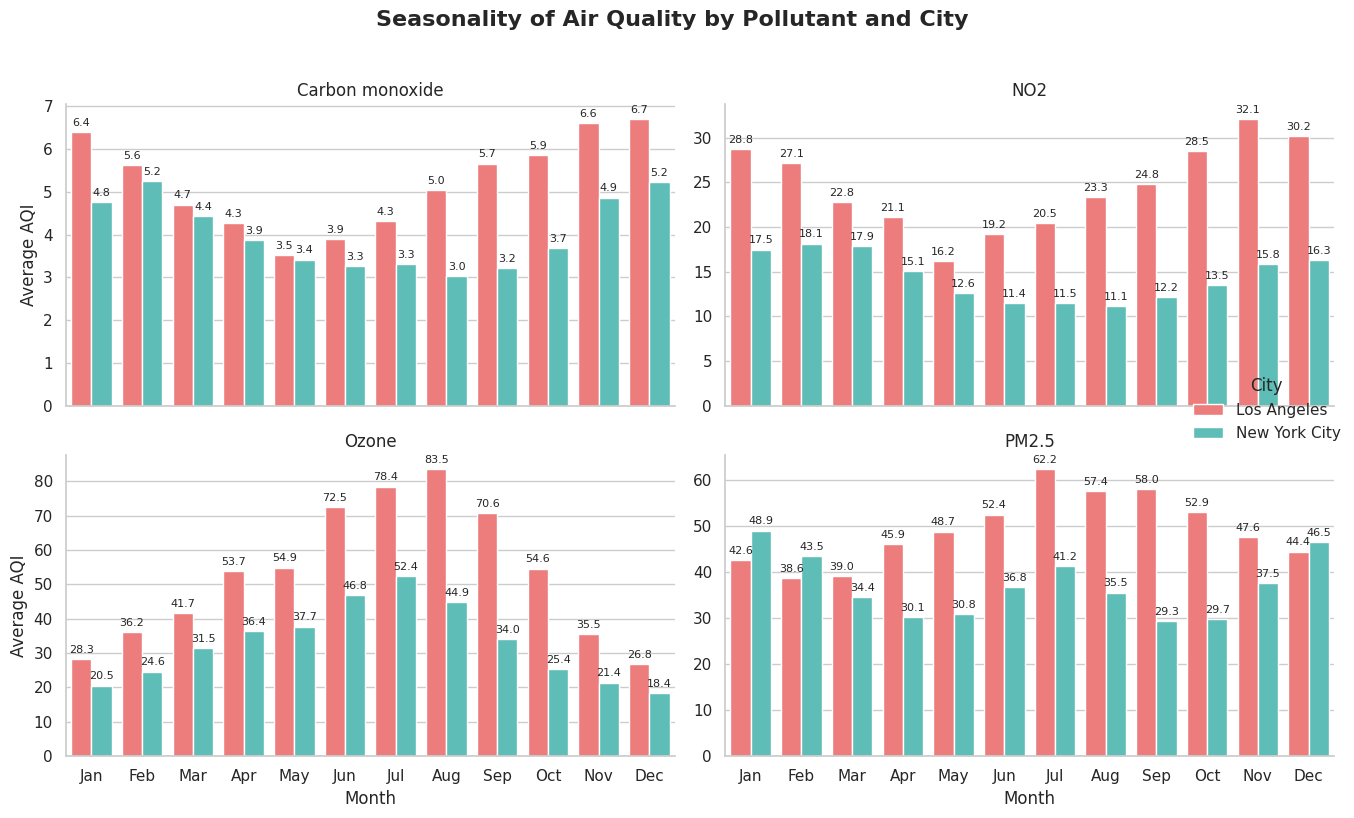

In [ ]:
#Grid of bar charts: one row per pollutant, one column per city
g = sns.catplot(
    data=combined_seasonal,
    kind='bar',
    x='Month',
    y='AQI',
    hue='City',  #shows both cities side-by-side for comparison
    col='Pollutant',  #creates a separate plot for each pollutant
    col_wrap=2,
    height=4,
    aspect=1.5,
    palette={'Los Angeles': '#FF6B6B', 'New York City': '#4ECDC4'},
    sharey=False,
    legend=True
)

g.fig.suptitle('Seasonality of Air Quality by Pollutant and City',
               fontsize=16, fontweight='bold', y=1.02)

#Axis labels
g.set_axis_labels("Month", "Average AQI")

#Individual plot titles
g.set_titles("{col_name}")

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for ax in g.axes.flat:
    ax.set_xticklabels(month_names)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()